## VISUALIZE QUERY RESULT
**D7 Retention Drop Analysis**

**1. Import libraries and settings**

In [88]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập style và font hiển thị sạch sẽ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [89]:
# path của DB và query config
db_path='game_analytics.duckdb'
query_path='query_config.xlsx'

**2. Connect DB and Get data**

In [90]:
# Connect với DB
conn=duckdb.connect(database='game_analytics.duckdb', read_only=True)

# Chọn schema
conn.execute(query='use core')

# Đọc file excel để lấy query
df_query=pd.read_excel(query_path)

# Nhóm lại thành dict
queries_dict = dict(zip(df_query['query_key'], df_query['sql_query']))

# Lấy dữ liệu từ DB
dfs={}
for key, query in queries_dict.items():
    dfs[key]=conn.execute(query=query).df()

# Preview
dfs

{'query_confirmed':   cohort_date  cohort_size  retained_d7  d7_retention_pct
 0  2026-03-01         7431         4010             53.96
 1  2026-03-02         6739         3300             48.97
 2  2026-03-03         6105         2674             43.80
 3  2026-03-04         5393         2169             40.22
 4  2026-03-05         4690         1563             33.33
 5  2026-03-06         4050         1015             25.06
 6  2026-03-07         3537          576             16.28,
 'query_q1':    cohort_date device_tier  total_sessions  avg_crash_per_session  \
 0   2026-03-01        High           52842                 0.0424   
 1   2026-03-01         Low           31670                 0.0570   
 2   2026-03-01         Mid           63551                 0.0512   
 3   2026-03-02        High           48180                 0.0435   
 4   2026-03-02         Low           25491                 0.0548   
 5   2026-03-02         Mid           56174                 0.0509   
 6   2

**3. Visualize**

Xác nhận vấn đề

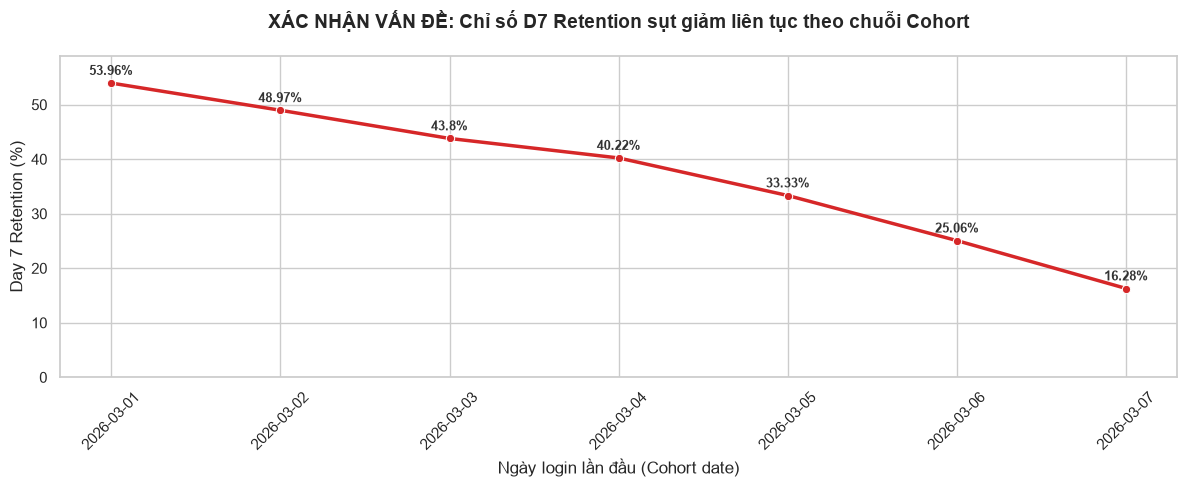

In [91]:
df_conf = dfs['query_confirmed']

# Chuyển đổi định dạng ngày nếu chưa chuẩn
df_conf['cohort_date'] = pd.to_datetime(df_conf['cohort_date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_conf, x='cohort_date', y='d7_retention_pct', marker='o', color='#d62728', linewidth=2.5)

# Điền nhãn dữ liệu lên từng điểm nút
for x, y in zip(df_conf['cohort_date'], df_conf['d7_retention_pct']):
    plt.text(x, y + 1, f"{y}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

plt.title("XÁC NHẬN VẤN ĐỀ: Chỉ số D7 Retention sụt giảm liên tục theo chuỗi Cohort", pad=20, weight='bold')
plt.xlabel("Ngày login lần đầu (Cohort date)")
plt.ylabel("Day 7 Retention (%)")
plt.ylim(0, df_conf['d7_retention_pct'].max() + 5)
plt.xticks(df_conf['cohort_date'], rotation=45)
plt.tight_layout()
plt.show()

Q1: Kiểm tra vấn đề kỹ thuật

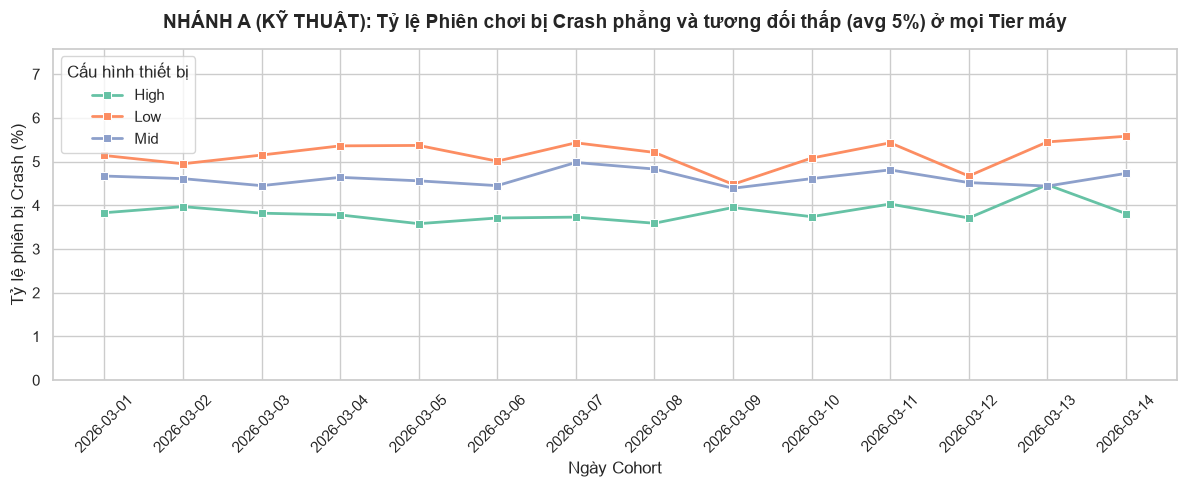

In [ ]:
df_q1 = dfs['query_q1']
df_q1['cohort_date'] = pd.to_datetime(df_q1['cohort_date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_q1, x='cohort_date', y='crash_session_rate_pct', hue='device_tier', marker='s', palette='Set2', linewidth=2)

plt.title("NHÁNH A (KỸ THUẬT): Tỷ lệ Phiên chơi bị Crash phẳng và tương đối thấp (avg 5%) ở mọi Tier máy", pad=15, weight='bold')
plt.xlabel("Ngày Cohort")
plt.ylabel("Tỷ lệ phiên bị Crash (%)")
plt.ylim(0, df_q1['crash_session_rate_pct'].max() + 2)
plt.xticks(df_q1['cohort_date'].unique(), rotation=45)
plt.legend(title="Cấu hình thiết bị")
plt.tight_layout()
plt.show()

Q2: Kiểm tra vấn đề UA

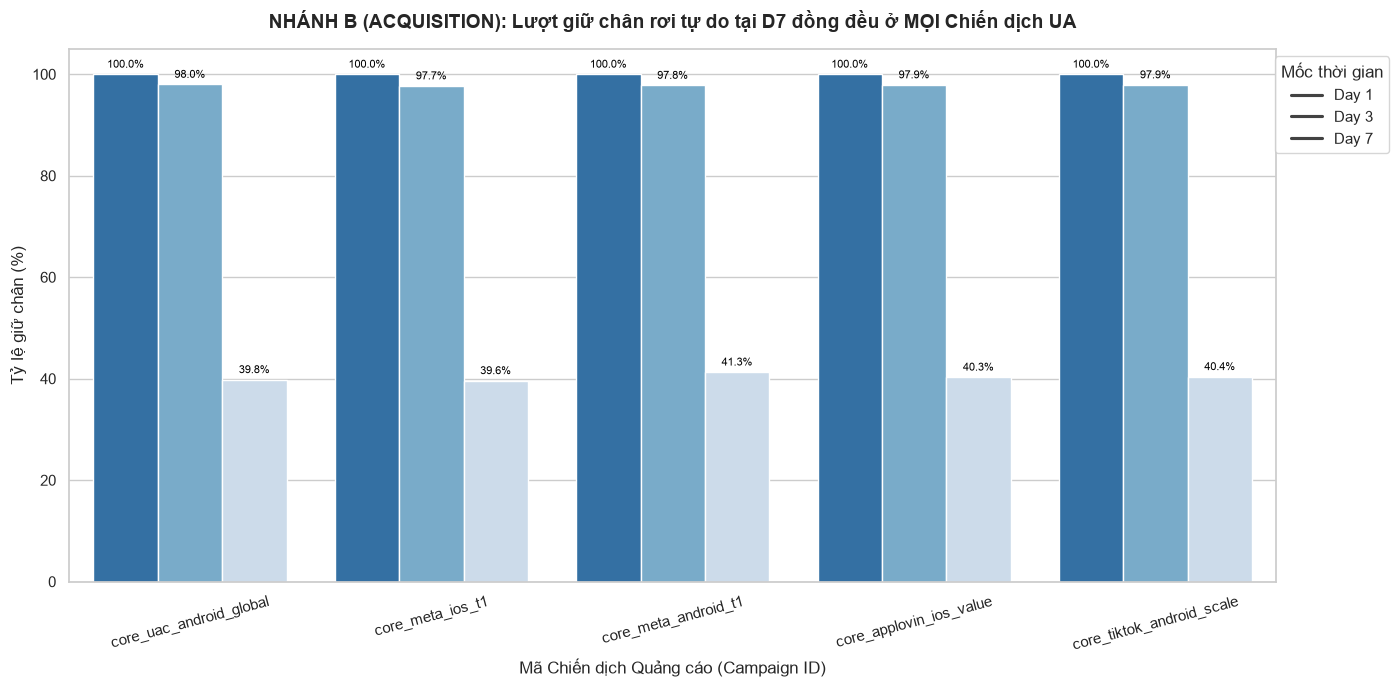

In [ ]:
df_q2 = dfs['query_q2'].head() # Lấy top 5 campaign lớn nhất để tránh rối mắt

# Melt data từ dạng rộng sang dạng dài phục vụ Seaborn hue
df_melted = df_q2.melt(id_vars=['channel', 'campaign_id'], value_vars=['d1_pct', 'd3_pct', 'd7_pct'], 
                       var_name='Retention_Day', value_name='Percentage')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_melted, x='campaign_id', y='Percentage', hue='Retention_Day', palette='Blues_r')

# Thêm số liệu trên đầu cột
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3), textcoords='offset points')

plt.title("NHÁNH B (ACQUISITION): Lượt giữ chân rơi tự do tại D7 đồng đều ở MỌI Chiến dịch UA", pad=15, weight='bold')
plt.xlabel("Mã Chiến dịch Quảng cáo (Campaign ID)")
plt.ylabel("Tỷ lệ giữ chân (%)")
plt.legend(title="Mốc thời gian", labels=['Day 1', 'Day 3', 'Day 7'], loc='upper right', bbox_to_anchor=(1.1, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Q3.1: Xác định ngày cuối cùng người chơi drop

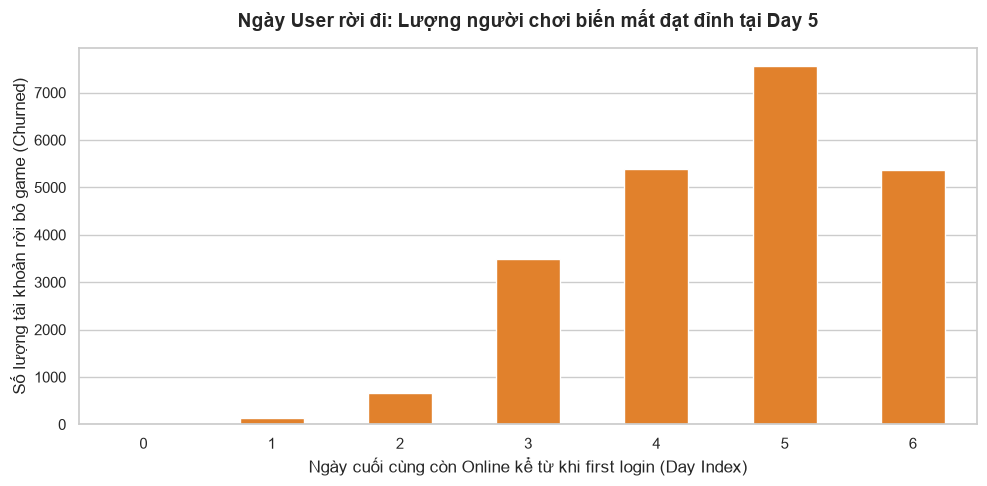

In [94]:
df_q3_1 = dfs['query_q3_1']

# Aggregate dữ liệu thu gọn góc nhìn tổng quát
df_dist = df_q3_1.groupby('last_active_dayidx')['churned_accounts'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_dist, x='last_active_dayidx', y='churned_accounts', color='#ff7f0e', width=0.5)

plt.title("Ngày User rời đi: Lượng người chơi biến mất đạt đỉnh tại Day 5", pad=15, weight='bold')
plt.xlabel("Ngày cuối cùng còn Online kể từ khi first login (Day Index)")
plt.ylabel("Số lượng tài khoản rời bỏ game (Churned)")
plt.tight_layout()
plt.show()

Q3.2: Hành vi người chơi trước khi drop

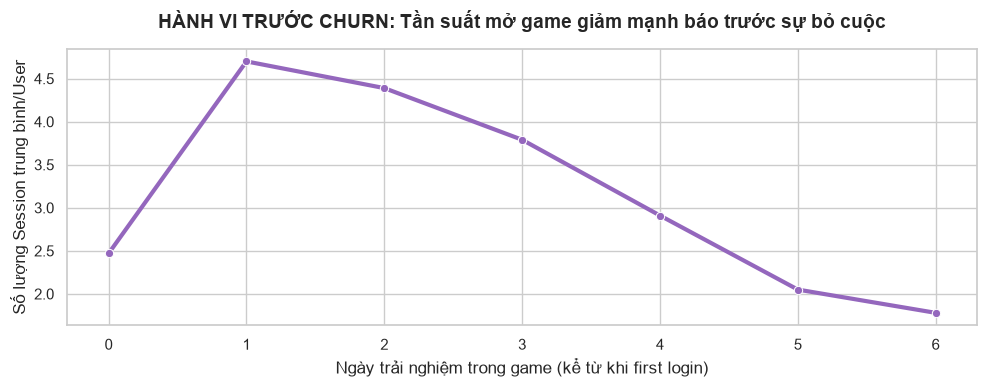

In [95]:
df_q3_2 = dfs['query_q3_2']

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_q3_2, x='day_idx', y='avg_sessions_per_user', marker='o', color='#9467bd', linewidth=3)

plt.title("HÀNH VI TRƯỚC CHURN: Tần suất mở game giảm mạnh báo trước sự bỏ cuộc", pad=15, weight='bold')
plt.xlabel("Ngày trải nghiệm trong game (kể từ khi first login)")
plt.ylabel("Số lượng Session trung bình/User")
plt.xticks(df_q3_2['day_idx'])
plt.tight_layout()
plt.show()

Q4.1: Chapter cuối cùng mà họ chơi trước khi drop hẳn

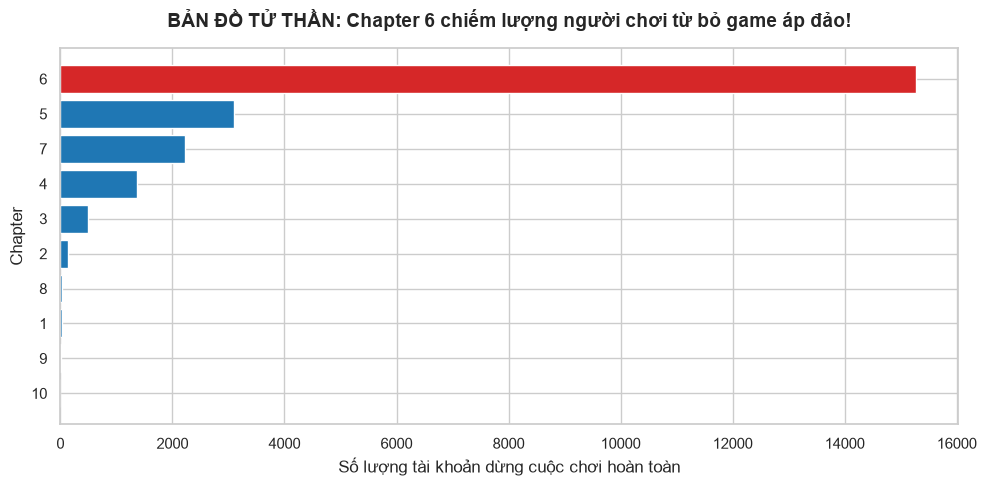

In [96]:
df_q4_1 = dfs['query_q4_1'].sort_values(by='drop_user_count', ascending=True)

# Đánh dấu màu đỏ riêng biệt cho Chương gây lỗi (Chapter 6) để tăng tính Storytelling
colors = ['#1f77b4' if x != 6 else '#d62728' for x in df_q4_1['chapter_id']]

plt.figure(figsize=(10, 5))
plt.barh(df_q4_1['chapter_id'].astype(str), df_q4_1['drop_user_count'], color=colors)

plt.title("BẢN ĐỒ TỬ THẦN: Chapter 6 chiếm lượng người chơi từ bỏ game áp đảo!", pad=15, weight='bold')
plt.xlabel("Số lượng tài khoản dừng cuộc chơi hoàn toàn")
plt.ylabel("Chapter")
plt.tight_layout()
plt.show()

Q4.2: Win rate tại điểm kẹt

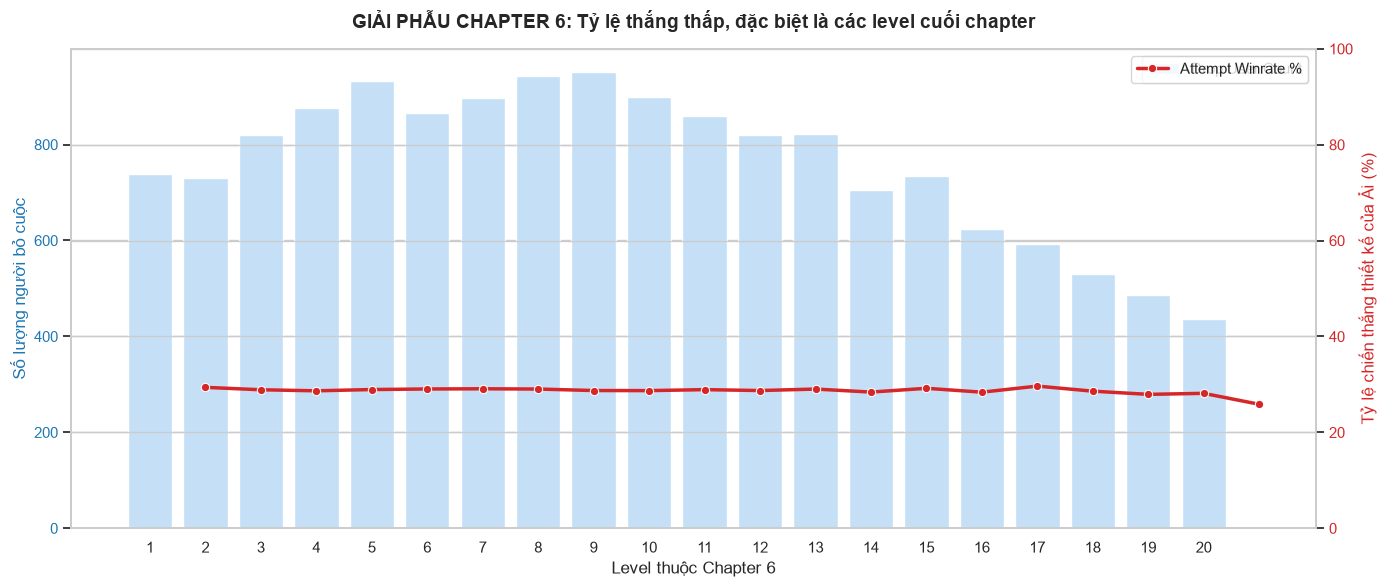

In [ ]:
df_q4_2 = dfs['query_q4_2'].sort_values(by='level_id')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1: Số lượng user drop tại từng Level thuộc Chapter 6
sns.barplot(data=df_q4_2, x='level_id', y='actual_drop_user_count', ax=ax1, color='#bde0fe', label='Drop User Count')
ax1.set_xlabel('Level thuộc Chapter 6')
ax1.set_ylabel('Số lượng người bỏ cuộc', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Trục 2: Đường biểu diễn tỷ lệ winrate của ải đó
ax2 = ax1.twinx()
sns.lineplot(data=df_q4_2, x='level_id', y='attempt_winrate', ax=ax2, color='#d62728', marker='o', linewidth=2.5, label='Attempt Winrate %')
ax2.set_ylabel('Tỷ lệ chiến thắng thiết kế của Ải (%)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 100)

plt.title("GIẢI PHẪU CHAPTER 6: Tỷ lệ thắng thấp, đặc biệt là các level cuối chapter", pad=15, weight='bold')
fig.tight_layout()
plt.show()

Q4.3: Người chơi có nỗ lực trước khi drop không?

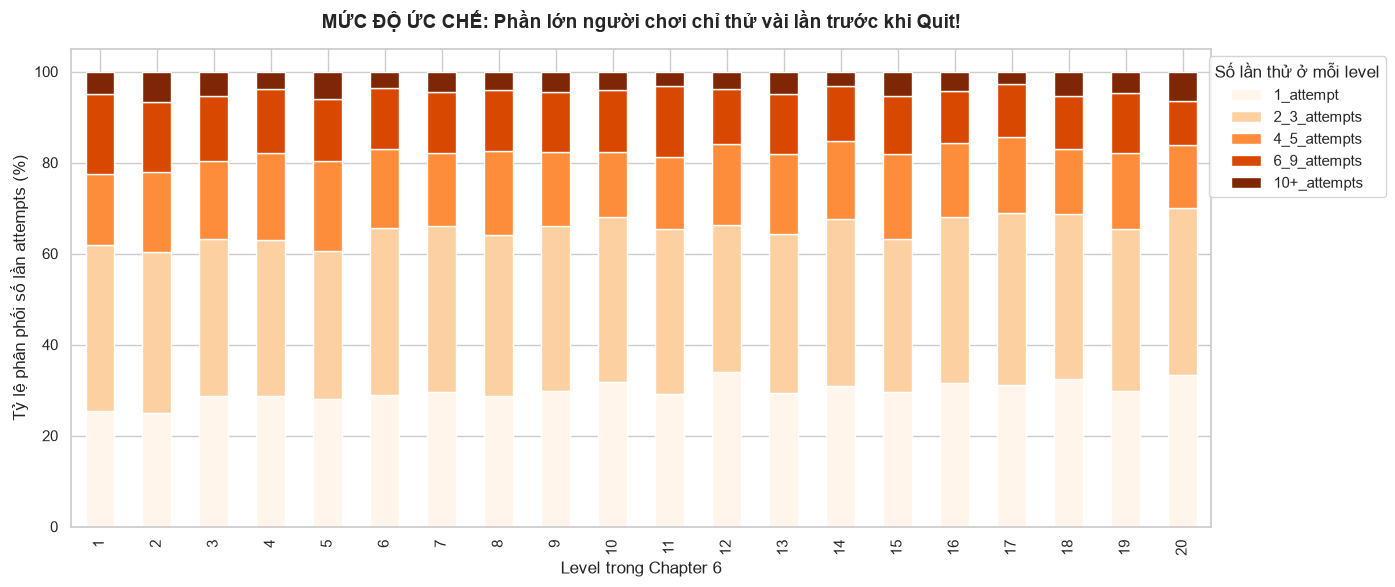

In [98]:
df_q4_3 = dfs['query_q4_3'].sort_values(by='level_id')

# Set level_id làm index để dễ plot dạng stacked
df_plot = df_q4_3.set_index('level_id')[['1_attempt', '2_3_attempts', '4_5_attempts', '6_9_attempts', '10+_attempts']]

# Cốt hóa dữ liệu thành tỷ lệ phần trăm tích lũy 100%
df_percentage = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

ax = df_percentage.plot(kind='bar', stacked=True, figsize=(14, 6), cmap='Oranges')

plt.title("MỨC ĐỘ ỨC CHẾ: Phần lớn người chơi chỉ thử vài lần trước khi Quit!", pad=15, weight='bold')
plt.xlabel("Level trong Chapter 6")
plt.ylabel("Tỷ lệ phân phối số lần attempts (%)")
plt.legend(title="Số lần thử ở mỗi level", loc='upper right', bbox_to_anchor=(1.16, 1))
plt.tight_layout()
plt.show()

Q5.1: Có sự khác biệt về D7 retention giữa nhóm F2P và Payer không?

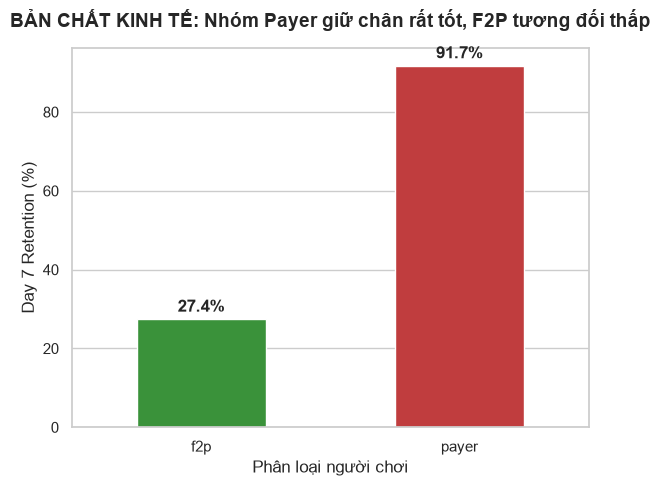

In [99]:
df_q5_1 = dfs['query_q5_1']

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=df_q5_1, x='user_type', y='d7_retention_pct', palette=['#2ca02c', '#d62728'], hue='user_type', width=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.title("BẢN CHẤT KINH TẾ: Nhóm Payer giữ chân rất tốt, F2P tương đối thấp", pad=15, weight='bold')
plt.xlabel("Phân loại người chơi")
plt.ylabel("Day 7 Retention (%)")
plt.tight_layout()
plt.show()

Q5.2: Người chơi F2P có cố gắng revive khi bị kẹt không?

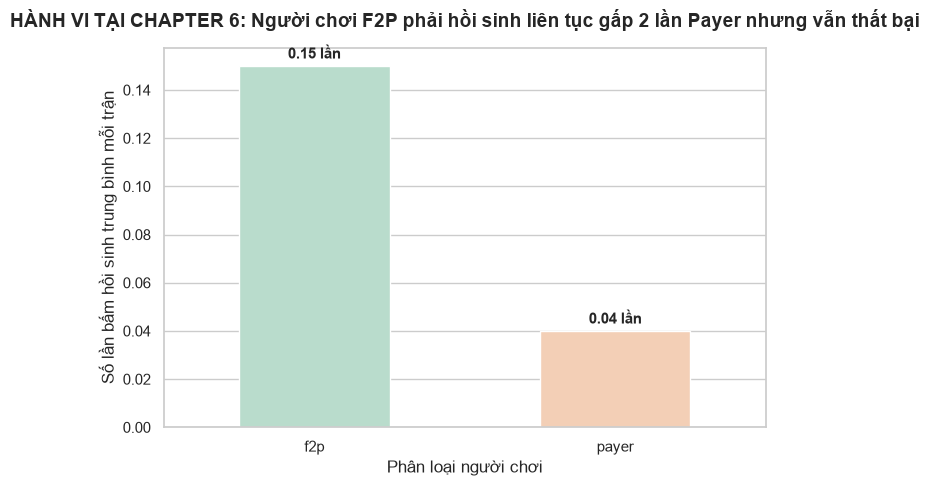

In [100]:
df_q5_2 = dfs['query_q5_2']

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=df_q5_2, x='user_type', y='avg_revive_per_attempt', palette='Pastel2', hue='user_type', width=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} lần", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.title("HÀNH VI TẠI CHAPTER 6: Người chơi F2P phải hồi sinh liên tục gấp 2 lần Payer nhưng vẫn thất bại", pad=15, weight='bold')
plt.xlabel("Phân loại người chơi")
plt.ylabel("Số lần bấm hồi sinh trung bình mỗi trận")
plt.tight_layout()
plt.show()

Q5.3: Sự khác nhau giữa nhóm churned và nhóm retained là gì?

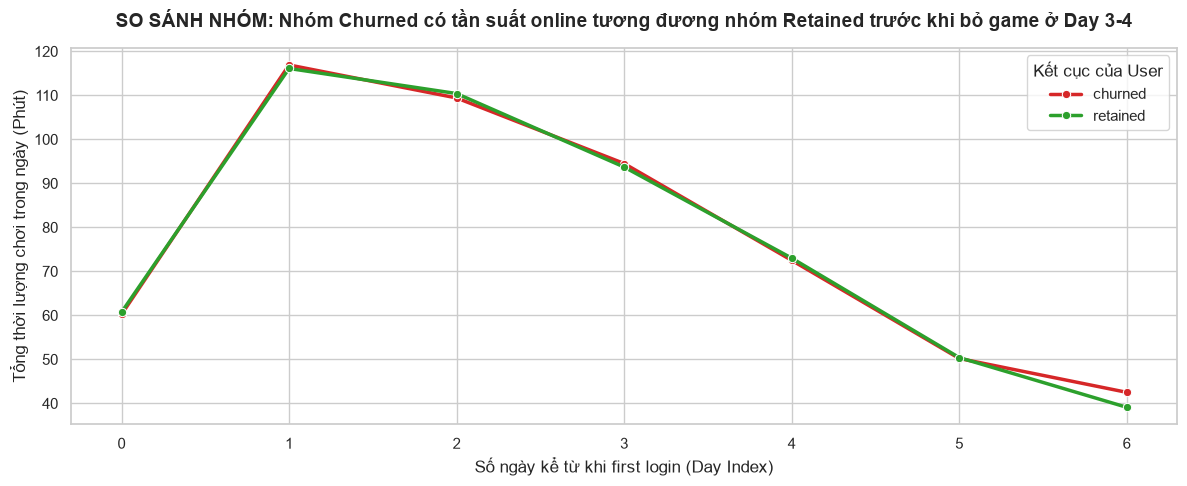

In [101]:
df_q5_3 = dfs['query_q5_3']

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_q5_3, x='day_idx', y='avg_total_playtime_min', hue='outcome', marker='o', 
             palette=['#d62728', '#2ca02c'], linewidth=2.5)

plt.title("SO SÁNH NHÓM: Nhóm Churned có tần suất online tương đương nhóm Retained trước khi bỏ game ở Day 3-4", pad=15, weight='bold')
plt.xlabel("Số ngày kể từ khi first login (Day Index)")
plt.ylabel("Tổng thời lượng chơi trong ngày (Phút)")
plt.xticks(df_q5_3['day_idx'].unique())
plt.legend(title="Kết cục của User")
plt.tight_layout()
plt.show()

In [102]:
conn.close()